In [ ]:
# 6.4. Überwachte Regression

## 1. Import Biblioteken

In [18]:
import pandas as pd
import numpy as np
import os

import matplotlib.pyplot as plt
import seaborn as sns

# Stil für schönere Grafiken
sns.set(style="whitegrid")


from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error

## 2. Daten laden

In [21]:
# ---------------------------------------------------------
# Bereinigten Datensatz laden
# ---------------------------------------------------------

base_path = r"C:\Users\faink\Desktop\Achievement_6\02_data\2_cleaned"
plot_path = r"C:\Users\faink\Desktop\Achievement_6\05_visual"


df = pd.read_csv(os.path.join(base_path, "cleaned_data.csv"))

df.head()

,country_final,region_final,happiness_final,gdp_final,social_support,health_final,freedom_final,generosity,corruption_final
0,Switzerland,Western Europe,7.587,1.39651,NaN,0.94143,0.66557,0.29678,0.41978
1,Iceland,Western Europe,7.561,1.30232,NaN,0.94784,0.62877,0.43630,0.14145
2,Denmark,Western Europe,7.527,1.32548,NaN,0.87464,0.64938,0.34139,0.48357
3,Norway,Western Europe,7.522,1.45900,NaN,0.88521,0.66973,0.34699,0.36503
4,Canada,North America,7.427,1.32629,NaN,0.90563,0.63297,0.45811,0.32957


## 3. Relevante Variablen auswählen

In [5]:
features = ["gdp_final", "social_support", "health_final", 
            "freedom_final", "generosity", "corruption_final"]

target = "happiness_final"

# Nur Zeilen ohne fehlende Werte verwenden
df_reg = df[features + [target]].dropna()

X = df_reg[features]
y = df_reg[target]

## 4. Train-Test-Split

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Trainingsgröße:", X_train.shape)
print("Testgröße:", X_test.shape)

Trainingsgröße: (490, 6)
Testgröße: (123, 6)


5. Modell erstellen und trainieren

In [7]:
model = LinearRegression()
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


## 6. Modellkoeffizienten anzeigen

In [8]:
coeff_df = pd.DataFrame({
    "Variable": features,
    "Koeffizient": model.coef_
})

print("Achsenabschnitt (Intercept):", model.intercept_)
coeff_df

Achsenabschnitt (Intercept): 1.2063262090064217


,Variable,Koeffizient
0,gdp_final,0.477363
1,social_support,2.488647
2,health_final,-0.042823
3,freedom_final,1.743957
4,generosity,0.441529
5,corruption_final,-1.016723


## 7. Vorhersagen und Modellbewertung

In [9]:
y_pred = model.predict(X_test)

r2 = r2_score(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)

print("R²-Wert:", r2)
print("MSE:", mse)
print("RMSE:", rmse)

R²-Wert: 0.6269635217686311
MSE: 0.44466661755241194
RMSE: 0.6668332756787201


## 8. Kurzer Interpretation

Das lineare Regressionsmodell untersucht, wie stark verschiedene Faktoren 
(GDP, soziale Unterstützung, Gesundheit, Freiheit, Großzügigkeit und Korruption) 
den Happiness Score eines Landes beeinflussen.

- **Koeffizienten** zeigen die Richtung und Stärke des Einflusses jeder Variable.  
  Ein positiver Koeffizient bedeutet, dass ein höherer Wert der Variable 
  den Happiness Score erhöht. Ein negativer Koeffizient bedeutet das Gegenteil.

- **R²-Wert** gibt an, wie viel der Varianz des Happiness Scores durch das Modell 
  erklärt wird. Ein höherer Wert bedeutet eine bessere Modellanpassung.

- **RMSE** misst den durchschnittlichen Vorhersagefehler. Je kleiner, desto besser.

Das Modell liefert eine quantitative Einschätzung, welche Faktoren den 
Happiness Score am stärksten beeinflussen und wie gut diese Faktoren 
gemeinsam die Unterschiede zwischen Ländern erklären.

## 9. Standardisierung (z‑Score)

In [10]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# In DataFrame zurückwandeln (optional, für Übersichtlichkeit)
X_scaled = pd.DataFrame(X_scaled, columns=features)

X_scaled.head()

,gdp_final,social_support,health_final,freedom_final,generosity,corruption_final
0,-0.870175,1.897859,-0.967774,0.342274,0.726540,-0.068388
1,-0.835244,1.864968,-0.968175,0.364225,1.250334,-0.224174
2,-0.859534,1.891281,-0.967959,0.351055,1.237863,-0.024298
3,-0.861384,2.068897,-0.966539,0.324713,1.668123,-0.817921
4,-0.843572,1.756424,-0.966138,0.250079,1.063265,-0.174205


## 10. Train-Test-Split mit standardisierten Date

In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

## 11. Regression mit standardisierten Variable

In [12]:
model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

## 12. Modellbewertung

In [15]:
r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("R²-Wert:", r2)
print("RMSE:", rmse)

R²-Wert: 0.6269635217686251
RMSE: 0.6668332756787255


## 13. Multikollinearität prüfen (VIF)

In [17]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

vif_data = pd.DataFrame()
vif_data["Variable"] = X_scaled.columns
vif_data["VIF"] = [variance_inflation_factor(X_scaled.values, i) 
                   for i in range(X_scaled.shape[1])]

vif_data

,Variable,VIF
0,gdp_final,95.453427
1,social_support,2.368787
2,health_final,107.736300
3,freedom_final,3.757965
4,generosity,1.821607
5,corruption_final,4.588936


## 14. Grafiken für Regression

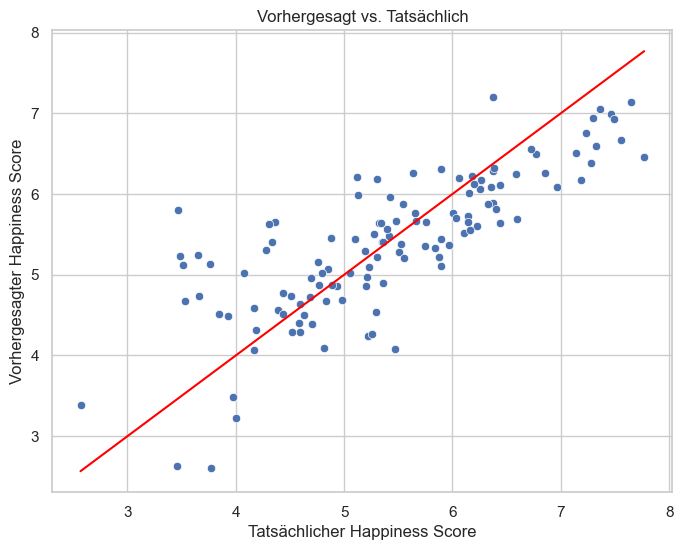

In [22]:
# ---------------------------------------------------------
# Scatterplot: Vorhergesagt vs. Tatsächlich
# ---------------------------------------------------------

plt.figure(figsize=(8,6))
sns.scatterplot(x=y_test, y=y_pred)
plt.xlabel("Tatsächlicher Happiness Score")
plt.ylabel("Vorhergesagter Happiness Score")
plt.title("Vorhergesagt vs. Tatsächlich")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color="red")

scatter_path = os.path.join(plot_path, "scatter_pred_vs_actual.png")
plt.savefig(scatter_path, dpi=300, bbox_inches="tight")
plt.show()

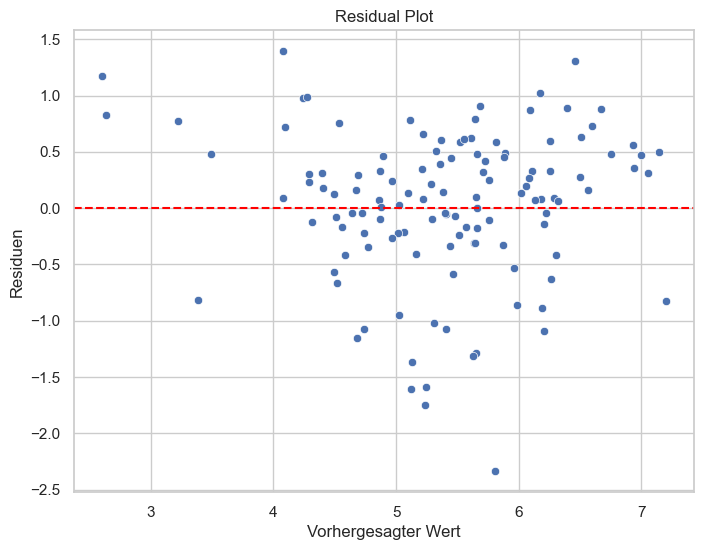

In [23]:
# ---------------------------------------------------------
# Residual Plot
# ---------------------------------------------------------

residuals = y_test - y_pred

plt.figure(figsize=(8,6))
sns.scatterplot(x=y_pred, y=residuals)
plt.axhline(0, color="red", linestyle="--")
plt.xlabel("Vorhergesagter Wert")
plt.ylabel("Residuen")
plt.title("Residual Plot")

residual_path = os.path.join(plot_path, "residual_plot.png")
plt.savefig(residual_path, dpi=300, bbox_inches="tight")
plt.show()

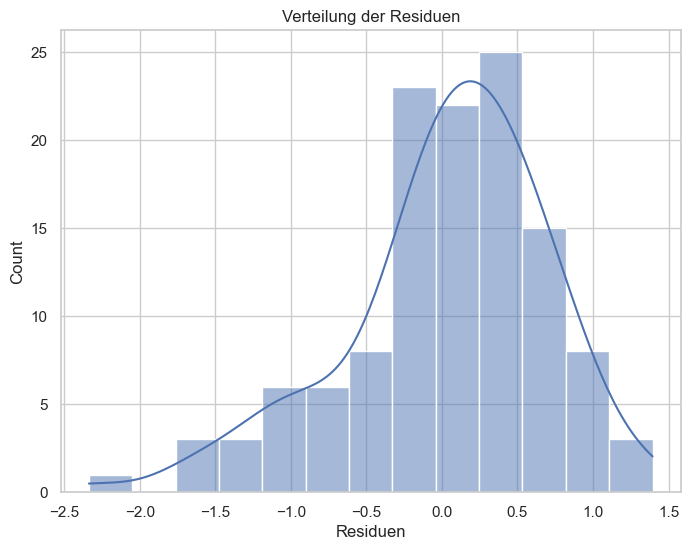

In [24]:
# ---------------------------------------------------------
# Histogramm der Residuen
# ---------------------------------------------------------

plt.figure(figsize=(8,6))
sns.histplot(residuals, kde=True)
plt.title("Verteilung der Residuen")
plt.xlabel("Residuen")

hist_path = os.path.join(plot_path, "residual_histogram.png")
plt.savefig(hist_path, dpi=300, bbox_inches="tight")
plt.show()

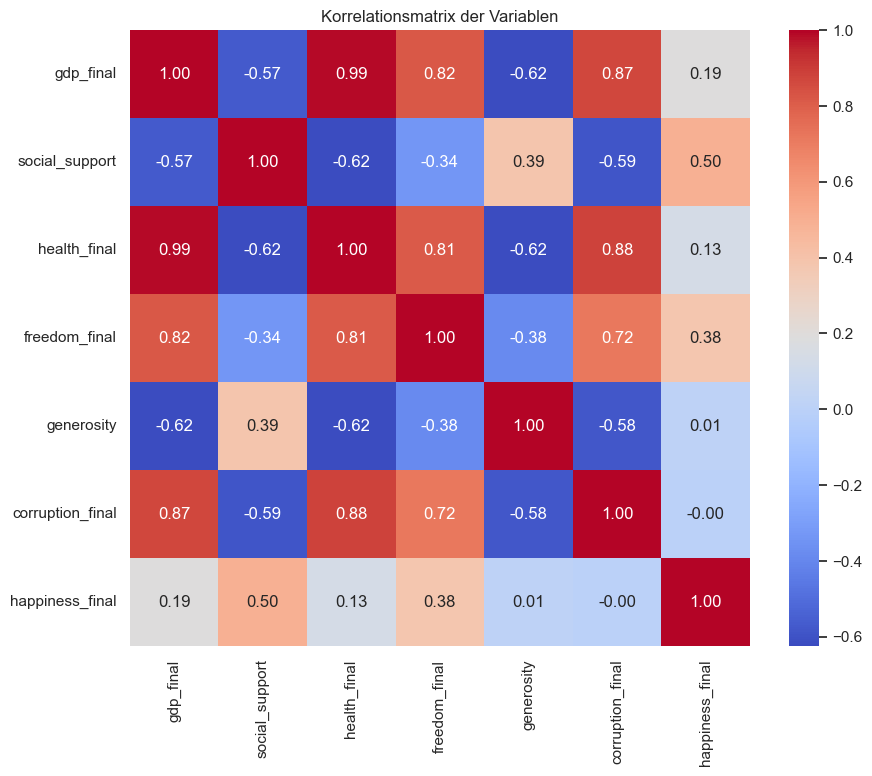

In [26]:
# ---------------------------------------------------------
# Korrelationsmatrix und Heatmap
# ---------------------------------------------------------

plt.figure(figsize=(10,8))
corr_matrix = df_reg.corr()

sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Korrelationsmatrix der Variablen")

heatmap_path = os.path.join(plot_path, "correlation_heatmap.png")
plt.savefig(heatmap_path, dpi=300, bbox_inches="tight")
plt.show()